# Direction B - Độ ổn định đặc trưng và diễn giải sinh học

Notebook này gộp **Direction B.1** và **Direction B.2** vào một.

**Mục tiêu:**

1. **B.1 — Đánh giá độ ổn định đặc trưng**
   - Lặp nhiều lần chia dữ liệu.
   - Mỗi lần chỉ chọn đặc trưng trên tập huấn luyện.
   - Đo hiệu năng mô hình và độ ổn định của các đặc trưng được chọn.

2. **B.2 — Diễn giải sinh học đặc trưng ổn định**
   - Lấy các đặc trưng được chọn lặp lại nhiều lần.
   - Gắn chú giải chức năng nếu có.
   - Phân nhóm đặc trưng: liên quan kháng thuốc rõ, vùng di động, điều hòa/vận chuyển, chưa rõ chức năng.


**Bản này giữ toàn bộ code cũ của Direction B** và bổ sung thêm một khối B.2 nâng cấp:
- gắn chú giải từ bảng Roary không chỉ bằng tên gene, mà còn bằng locus tag trong các cột isolate;
- tạo bảng chú giải nâng cấp cho top đặc trưng ổn định;
- lưu thêm các file kết quả chú giải nâng cấp.


## 0. Cấu hình chạy
- `FEATURE_COUNTS`: số đặc trưng chọn lại từ ma trận gen phụ.

In [1]:
# =========================
# CẤU HÌNH CHÍNH
# =========================

N_SPLITS = 30
FEATURE_COUNTS = [50, 200]
TEST_SIZE = 0.2
RANDOM_SEED_BASE = 42

# Để False cho chạy nhanh. Đổi True nếu muốn thêm XGBoost.
RUN_XGBOOST = False

DRUGS = ["AMP", "AUG", "AXO", "CHL", "FOX"]

# Thư mục làm việc tạm trên Colab, không dùng Drive.
BASE_DIR = "/content/salmonella_direction_B"
REPO_URL = "https://github.com/347251369/Antimicrobial-resistance-prediction-in-Salmonella.git"
REPO_DIR = f"{BASE_DIR}/Antimicrobial-resistance-prediction-in-Salmonella"
OUTPUT_DIR = f"{BASE_DIR}/outputs"
EXTRACT_DIR = f"{BASE_DIR}/extracted"

print("BASE_DIR:", BASE_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_DIR: /content/salmonella_direction_B
OUTPUT_DIR: /content/salmonella_direction_B/outputs


## 1. Set up

Notebook sẽ sao chép kho GitHub vào bộ nhớ tạm của Colab.  
Nếu thư mục đã tồn tại, notebook sẽ không sao chép lại.

In [2]:
import os
from pathlib import Path

Path(BASE_DIR).mkdir(parents=True, exist_ok=True)
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
Path(EXTRACT_DIR).mkdir(parents=True, exist_ok=True)

%cd /content

# Cài unrar để giải nén các file .rar nếu cần.
!apt-get update -qq
!apt-get install -y -qq unrar > /dev/null

# Clone GitHub nếu chưa có.
if not Path(REPO_DIR).exists():
    !git clone --depth 1 {REPO_URL} {REPO_DIR}
else:
    print("Repo đã tồn tại, bỏ qua bước git clone.")

print("Kiểm tra repo:")
!find {REPO_DIR} -maxdepth 3 -type d | head -50

/content
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Cloning into '/content/salmonella_direction_B/Antimicrobial-resistance-prediction-in-Salmonella'...
remote: Enumerating objects: 79, done.
remote: Counting objects: 100% (79/79), done.
remote: Compressing objects: 100% (53/53), done.
remote: Total 79 (delta 33), reused 54 (delta 25), pack-reused 0 (from 0)
Receiving objects: 100% (79/79), 2.95 MiB | 11.97 MiB/s, done.
Resolving deltas: 100% (33/33), done.
Kiểm tra repo:
/content/salmonella_direction_B/Antimicrobial-resistance-prediction-in-Salmonella
/content/salmonella_direction_B/Antimicrobial-resistance-prediction-in-Salmonella/results
/content/salmonella_direction_B/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary
/content/salmonella_direction_B/Antimicrobial-resistance-prediction-in-Salmonella/results/chi-square test
/con

## 2. Import thư viện

In [3]:
import os
import re
import json
import math
import shutil
import warnings
from pathlib import Path
from itertools import combinations
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

from IPython.display import display, Markdown

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

warnings.filterwarnings("ignore")

try:
    import xgboost as xgb
    HAS_XGBOOST = True
except Exception as e:
    HAS_XGBOOST = False
    print("Không import được xgboost:", e)

print("HAS_XGBOOST:", HAS_XGBOOST)

HAS_XGBOOST: True


## 3. Đọc dữ liệu

Bộ dữ liệu có hai phần quan trọng:

1. `data/csv/<thuốc>/gene.csv` và `<thuốc>_label.csv`: 50 đặc trưng đã chọn sẵn theo từng thuốc.
2. `results/Roary/accessory gene existence matrix.rar`: ma trận gen phụ đầy đủ, dùng để chọn lại đặc trưng trong tập huấn luyện.

In [4]:
def clean_col_name(x):
    return str(x).strip()

def list_files(root, suffixes=None):
    root = Path(root)
    if not root.exists():
        return []
    files = []
    for p in root.rglob("*"):
        if p.is_file():
            if suffixes is None or p.suffix.lower() in suffixes:
                files.append(p)
    return sorted(files, key=lambda x: x.stat().st_size, reverse=True)

def read_csv_flexible(path):
    path = Path(path)
    # Thử các delimiter phổ biến.
    for sep in [",", "\t", ";"]:
        try:
            df = pd.read_csv(path, sep=sep, low_memory=False)
            if df.shape[1] > 1:
                df.columns = [clean_col_name(c) for c in df.columns]
                return df
        except Exception:
            pass
    # fallback
    df = pd.read_csv(path, low_memory=False)
    df.columns = [clean_col_name(c) for c in df.columns]
    return df

def make_binary_label(y_raw):
    y = pd.Series(y_raw).copy()
    y = y.replace({
        "S": 0, "s": 0,
        "I": 0, "i": 0,
        "R": 1, "r": 1,
        "Susceptible": 0, "Intermediate": 0, "Resistant": 1,
        "susceptible": 0, "intermediate": 0, "resistant": 1,
        False: 0, True: 1
    })
    # Nếu là float/int dạng 0/1
    y = pd.to_numeric(y, errors="coerce")
    if y.isna().any():
        bad = y_raw[pd.isna(y)].head()
        raise ValueError(f"Nhãn có giá trị không chuyển được sang 0/1. Ví dụ: {bad}")
    return y.astype(int)

def load_ready_50_for_drug(drug):
    drug_dir = Path(REPO_DIR) / "data" / "csv" / drug
    x_path = drug_dir / "gene.csv"
    y_path = drug_dir / f"{drug}_label.csv"

    if not x_path.exists():
        raise FileNotFoundError(f"Không tìm thấy {x_path}")
    if not y_path.exists():
        raise FileNotFoundError(f"Không tìm thấy {y_path}")

    X = read_csv_flexible(x_path)
    y_df = read_csv_flexible(y_path)

    # lấy cột nhãn
    if y_df.shape[1] == 1:
        y = make_binary_label(y_df.iloc[:, 0])
    else:
        possible = [c for c in y_df.columns if "label" in c.lower() or drug.lower() in c.lower()]
        if possible:
            y = make_binary_label(y_df[possible[0]])
        else:
            y = make_binary_label(y_df.iloc[:, -1])

    # bỏ cột dạng text nếu có
    X2 = X.copy()
    for col in list(X2.columns):
        if X2[col].dtype == "object":
            try:
                X2[col] = pd.to_numeric(X2[col])
            except Exception:
                X2 = X2.drop(columns=[col])
    X2 = X2.fillna(0)
    X2.columns = [clean_col_name(c) for c in X2.columns]

    if len(X2) != len(y):
        raise ValueError(f"{drug}: X và y không cùng số dòng: {X2.shape}, {y.shape}")
    return X2, y

def extract_rar_if_needed(rar_path, out_dir):
    rar_path = Path(rar_path)
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    existing_tables = list_files(out_dir, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"])
    if existing_tables:
        return existing_tables
    if not rar_path.exists():
        print("Không thấy file rar:", rar_path)
        return []
    print("Đang giải nén:", rar_path)
    !unrar x -o+ "{rar_path}" "{out_dir}/" > /dev/null
    return list_files(out_dir, suffixes=[".csv", ".tsv", ".txt", ".xlsx", ".xls"])

def load_full_accessory_matrix():
    rar_path = Path(REPO_DIR) / "results" / "Roary" / "accessory gene existence matrix.rar"
    out_dir = Path(EXTRACT_DIR) / "accessory_gene"
    tables = extract_rar_if_needed(rar_path, out_dir)
    if not tables:
        raise FileNotFoundError("Không tìm thấy bảng ma trận gen phụ sau giải nén.")
    # lấy bảng lớn nhất
    table_path = tables[0]
    print("Đọc ma trận gen phụ:", table_path, f"({table_path.stat().st_size/1e6:.2f} MB)")
    df = read_csv_flexible(table_path)
    print("Raw accessory shape:", df.shape)

    # bỏ các cột định danh/text, chỉ giữ số
    X = df.copy()
    dropped = []
    for col in list(X.columns):
        if X[col].dtype == "object":
            try:
                X[col] = pd.to_numeric(X[col])
            except Exception:
                dropped.append(col)
                X = X.drop(columns=[col])
    X = X.fillna(0)
    X.columns = [clean_col_name(c) for c in X.columns]

    # đưa về 0/1 nếu có giá trị lạ
    # Ma trận gen phụ thường là 0/1, nhưng ta ép an toàn.
    for col in X.columns:
        if not pd.api.types.is_numeric_dtype(X[col]):
            X[col] = pd.to_numeric(X[col], errors="coerce").fillna(0)
    X = (X > 0).astype(int)

    print("Accessory numeric shape:", X.shape)
    print("Số cột text bị bỏ:", len(dropped))
    if dropped[:5]:
        print("Ví dụ cột bị bỏ:", dropped[:5])
    return X, table_path

def load_roary_annotations():
    # Thử lấy annotation từ gene_presence_absence.rar nếu có.
    rar_path = Path(REPO_DIR) / "results" / "Roary" / "gene_presence_absence.rar"
    out_dir = Path(EXTRACT_DIR) / "gene_presence_absence"
    tables = extract_rar_if_needed(rar_path, out_dir)
    if not tables:
        print("Không có bảng Roary annotation.")
        return {}

    # tìm file có gene_presence_absence
    table_path = None
    for p in tables:
        if "gene_presence_absence" in p.name.lower():
            table_path = p
            break
    if table_path is None:
        table_path = tables[0]

    try:
        df = read_csv_flexible(table_path)
    except Exception as e:
        print("Không đọc được Roary annotation:", e)
        return {}

    print("Roary annotation raw shape:", df.shape)
    ann = {}
    cols = {c.lower(): c for c in df.columns}
    gene_col = cols.get("gene", None)
    nonunique_col = cols.get("non-unique gene name", None)
    annotation_col = cols.get("annotation", None)

    if annotation_col is None:
        print("Không thấy cột Annotation trong Roary.")
        return {}

    for _, row in df.iterrows():
        annot = str(row.get(annotation_col, "")).strip()
        if not annot or annot.lower() == "nan":
            continue
        keys = []
        if gene_col is not None:
            keys.append(str(row.get(gene_col, "")).strip())
        if nonunique_col is not None:
            keys.append(str(row.get(nonunique_col, "")).strip())
        for k in keys:
            if k and k.lower() != "nan":
                ann[k] = annot
    print("Số annotation lấy từ Roary:", len(ann))
    return ann

## 4. Đọc dữ liệu nhãn, dữ liệu 50 đặc trưng có sẵn và ma trận gen phụ đầy đủ

In [5]:
ready_data = {}
dataset_summary_rows = []

for drug in DRUGS:
    X_ready, y = load_ready_50_for_drug(drug)
    ready_data[drug] = {"X_ready": X_ready, "y": y}
    dataset_summary_rows.append({
        "drug": drug,
        "n_samples": len(y),
        "n_ready_features": X_ready.shape[1],
        "n_resistant": int(y.sum()),
        "n_non_resistant": int((y == 0).sum()),
        "resistant_rate": float(y.mean())
    })

dataset_summary = pd.DataFrame(dataset_summary_rows)
display(dataset_summary)

X_accessory, accessory_path = load_full_accessory_matrix()

# Kiểm tra số dòng có khớp 1167 không
print("Full accessory matrix:", X_accessory.shape)
print("Số mẫu nhãn:", {drug: len(ready_data[drug]['y']) for drug in DRUGS})

if X_accessory.shape[0] != len(ready_data[DRUGS[0]]["y"]):
    raise ValueError("Số dòng ma trận gen phụ không khớp số nhãn. Cần kiểm tra thứ tự mẫu.")

,drug,n_samples,n_ready_features,n_resistant,n_non_resistant,resistant_rate
0,AMP,1167,50,199,968,0.170523
1,AUG,1167,50,139,1028,0.119109
2,AXO,1167,50,71,1096,0.060840
3,CHL,1167,50,126,1041,0.107969
4,FOX,1167,50,71,1096,0.060840


Đang giải nén: /content/salmonella_direction_B/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/accessory gene existence matrix.rar
Đọc ma trận gen phụ: /content/salmonella_direction_B/extracted/accessory_gene/accessory gene existence matrix.csv (42.56 MB)
Raw accessory shape: (1167, 18126)
Accessory numeric shape: (1167, 18125)
Số cột text bị bỏ: 1
Ví dụ cột bị bỏ: ['Unnamed: 0']
Full accessory matrix: (1167, 18125)
Số mẫu nhãn: {'AMP': 1167, 'AUG': 1167, 'AXO': 1167, 'CHL': 1167, 'FOX': 1167}


## 5. Hàm mô hình, đánh giá và đo độ ổn định

- Đặc trưng được chọn bằng kiểm định chi bình phương.
- Chi bình phương chỉ được fit trên tập huấn luyện.
- Tập kiểm tra không tham gia chọn đặc trưng.
- Độ ổn định đặc trưng được đo bằng chỉ số Jaccard giữa các tập đặc trưng được chọn ở nhiều lần chia.

In [6]:
def get_models():
    models = {
        "logistic_regression": LogisticRegression(
            max_iter=10000,
            class_weight="balanced",
            solver="liblinear",
            random_state=0
        )
    }
    if RUN_XGBOOST and HAS_XGBOOST:
        models["xgboost"] = xgb.XGBClassifier(
            n_estimators=250,
            max_depth=4,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric="logloss",
            random_state=0,
            n_jobs=2
        )
    return models

def evaluate_model(model, X_train, y_train, X_test, y_test):
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    if hasattr(model, "predict_proba"):
        prob = model.predict_proba(X_test)[:, 1]
    else:
        # fallback, không lý tưởng nhưng an toàn
        prob = pred

    out = {
        "balanced_accuracy": balanced_accuracy_score(y_test, pred),
        "f1": f1_score(y_test, pred, zero_division=0),
        "auroc": roc_auc_score(y_test, prob) if len(np.unique(y_test)) == 2 else np.nan,
        "auprc": average_precision_score(y_test, prob),
    }
    return out

def mean_pairwise_jaccard(list_of_sets):
    if len(list_of_sets) < 2:
        return np.nan, np.nan
    vals = []
    for a, b in combinations(list_of_sets, 2):
        union = len(a | b)
        inter = len(a & b)
        vals.append(inter / union if union else np.nan)
    vals = np.array(vals, dtype=float)
    return float(np.nanmean(vals)), float(np.nanstd(vals))

def run_direction_B_for_drug(drug, X_accessory, y, feature_counts, n_splits):
    rows = []
    selected_sets = defaultdict(list)
    selected_counters = defaultdict(Counter)

    seeds = [RANDOM_SEED_BASE + i for i in range(n_splits)]
    models = get_models()

    for split_id, seed in enumerate(seeds):
        X_train_full, X_test_full, y_train, y_test = train_test_split(
            X_accessory,
            y,
            test_size=TEST_SIZE,
            random_state=seed,
            stratify=y
        )

        for k in feature_counts:
            k_eff = min(k, X_accessory.shape[1])

            selector = SelectKBest(score_func=chi2, k=k_eff)
            selector.fit(X_train_full, y_train)
            selected_mask = selector.get_support()
            selected_features = list(X_accessory.columns[selected_mask])
            selected_set = set(selected_features)

            selected_sets[k].append(selected_set)
            selected_counters[k].update(selected_features)

            X_train_sel = X_train_full.loc[:, selected_features]
            X_test_sel = X_test_full.loc[:, selected_features]

            for model_name, model in models.items():
                metrics = evaluate_model(model, X_train_sel, y_train, X_test_sel, y_test)
                rows.append({
                    "drug": drug,
                    "split_id": split_id,
                    "seed": seed,
                    "setting": f"train_only_chi2_select_{k}_from_full_accessory",
                    "k_features": k,
                    "model": model_name,
                    **metrics
                })

    perf_df = pd.DataFrame(rows)

    jaccard_rows = []
    for k, sets in selected_sets.items():
        mean_j, std_j = mean_pairwise_jaccard(sets)
        jaccard_rows.append({
            "drug": drug,
            "k_features": k,
            "setting": f"train_only_chi2_select_{k}_from_full_accessory",
            "jaccard_mean": mean_j,
            "jaccard_std": std_j,
            "n_splits": len(sets)
        })
    jaccard_df = pd.DataFrame(jaccard_rows)

    feature_rows = []
    for k, counter in selected_counters.items():
        for feat, count in counter.most_common():
            feature_rows.append({
                "drug": drug,
                "k_features": k,
                "setting": f"train_only_chi2_select_{k}_from_full_accessory",
                "feature": feat,
                "selected_count": count,
                "selected_frequency": count / n_splits
            })
    stable_df = pd.DataFrame(feature_rows)

    return perf_df, jaccard_df, stable_df

def summarize_performance(perf_df):
    group_cols = ["drug", "setting", "k_features", "model"]
    metrics = ["balanced_accuracy", "f1", "auroc", "auprc"]
    out = perf_df.groupby(group_cols)[metrics].agg(["mean", "std"]).reset_index()
    out.columns = ["_".join([str(x) for x in c if x != ""]) for c in out.columns]
    return out.sort_values(["drug", "balanced_accuracy_mean", "auprc_mean"], ascending=[True, False, False])

def best_by_drug(perf_summary):
    best_rows = []
    for drug, sub in perf_summary.groupby("drug"):
        sub2 = sub.sort_values(["balanced_accuracy_mean", "auprc_mean"], ascending=False)
        best_rows.append(sub2.iloc[0])
    return pd.DataFrame(best_rows).reset_index(drop=True)

## 6. Chạy Direction B.1 - hiệu năng và độ ổn định đặc trưng


In [7]:
all_perf = []
all_jaccard = []
all_stable = []

for drug in DRUGS:
    print("\n" + "="*80)
    print("Đang chạy Direction B cho thuốc:", drug)
    y = ready_data[drug]["y"].reset_index(drop=True)

    perf_df, jaccard_df, stable_df = run_direction_B_for_drug(
        drug=drug,
        X_accessory=X_accessory.reset_index(drop=True),
        y=y,
        feature_counts=FEATURE_COUNTS,
        n_splits=N_SPLITS
    )

    all_perf.append(perf_df)
    all_jaccard.append(jaccard_df)
    all_stable.append(stable_df)

    print("Done:", drug)

perf_all = pd.concat(all_perf, ignore_index=True)
jaccard_all = pd.concat(all_jaccard, ignore_index=True)
stable_all = pd.concat(all_stable, ignore_index=True)

perf_summary = summarize_performance(perf_all)
best_summary = best_by_drug(perf_summary)

print("\nTóm tắt hiệu năng:")
display(perf_summary)

print("\nThiết lập tốt nhất theo từng thuốc:")
display(best_summary)

print("\nTóm tắt độ ổn định Jaccard:")
display(jaccard_all)


Đang chạy Direction B cho thuốc: AMP
Done: AMP

Đang chạy Direction B cho thuốc: AUG
Done: AUG

Đang chạy Direction B cho thuốc: AXO
Done: AXO

Đang chạy Direction B cho thuốc: CHL
Done: CHL

Đang chạy Direction B cho thuốc: FOX
Done: FOX

Tóm tắt hiệu năng:


,drug,setting,k_features,model,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std
0,AMP,train_only_chi2_select_200_from_full_accessory,200,logistic_regression,0.917247,0.030481,0.863356,0.046805,0.944330,0.026902,0.904099,0.041013
1,AMP,train_only_chi2_select_50_from_full_accessory,50,logistic_regression,0.858222,0.040295,0.729164,0.072418,0.898582,0.047000,0.809573,0.073279
2,AUG,train_only_chi2_select_200_from_full_accessory,200,logistic_regression,0.975693,0.015271,0.943398,0.021083,0.983088,0.022555,0.954468,0.030750
3,AUG,train_only_chi2_select_50_from_full_accessory,50,logistic_regression,0.969990,0.017818,0.929016,0.028834,0.975948,0.018948,0.931517,0.038035
4,AXO,train_only_chi2_select_200_from_full_accessory,200,logistic_regression,0.981461,0.024102,0.970858,0.026525,0.993858,0.013785,0.987174,0.026275
5,AXO,train_only_chi2_select_50_from_full_accessory,50,logistic_regression,0.966320,0.032385,0.927339,0.050531,0.970850,0.029096,0.942255,0.054462
6,CHL,train_only_chi2_select_200_from_full_accessory,200,logistic_regression,0.926533,0.027324,0.867248,0.040933,0.942341,0.029709,0.900978,0.041219
7,CHL,train_only_chi2_select_50_from_full_accessory,50,logistic_regression,0.917474,0.027674,0.845506,0.061322,0.942293,0.028722,0.886289,0.043977
9,FOX,train_only_chi2_select_50_from_full_accessory,50,logistic_regression,0.973539,0.027133,0.936000,0.042650,0.982781,0.020622,0.962827,0.038489
8,FOX,train_only_chi2_select_200_from_full_accessory,200,logistic_regression,0.969481,0.026680,0.957409,0.036546,0.983274,0.020173,0.965592,0.038738



Thiết lập tốt nhất theo từng thuốc:


,drug,setting,k_features,model,balanced_accuracy_mean,balanced_accuracy_std,f1_mean,f1_std,auroc_mean,auroc_std,auprc_mean,auprc_std
0,AMP,train_only_chi2_select_200_from_full_accessory,200,logistic_regression,0.917247,0.030481,0.863356,0.046805,0.944330,0.026902,0.904099,0.041013
1,AUG,train_only_chi2_select_200_from_full_accessory,200,logistic_regression,0.975693,0.015271,0.943398,0.021083,0.983088,0.022555,0.954468,0.030750
2,AXO,train_only_chi2_select_200_from_full_accessory,200,logistic_regression,0.981461,0.024102,0.970858,0.026525,0.993858,0.013785,0.987174,0.026275
3,CHL,train_only_chi2_select_200_from_full_accessory,200,logistic_regression,0.926533,0.027324,0.867248,0.040933,0.942341,0.029709,0.900978,0.041219
4,FOX,train_only_chi2_select_50_from_full_accessory,50,logistic_regression,0.973539,0.027133,0.936000,0.042650,0.982781,0.020622,0.962827,0.038489



Tóm tắt độ ổn định Jaccard:


,drug,k_features,setting,jaccard_mean,jaccard_std,n_splits
0,AMP,50,train_only_chi2_select_50_from_full_accessory,0.809773,0.100585,30
1,AMP,200,train_only_chi2_select_200_from_full_accessory,0.826004,0.060758,30
2,AUG,50,train_only_chi2_select_50_from_full_accessory,0.782738,0.177494,30
3,AUG,200,train_only_chi2_select_200_from_full_accessory,0.877712,0.047920,30
4,AXO,50,train_only_chi2_select_50_from_full_accessory,0.773257,0.126790,30
5,AXO,200,train_only_chi2_select_200_from_full_accessory,0.951716,0.030009,30
6,CHL,50,train_only_chi2_select_50_from_full_accessory,0.746135,0.135882,30
7,CHL,200,train_only_chi2_select_200_from_full_accessory,0.805167,0.096816,30
8,FOX,50,train_only_chi2_select_50_from_full_accessory,0.831844,0.086778,30
9,FOX,200,train_only_chi2_select_200_from_full_accessory,0.960791,0.019980,30


## 7. Kiểm tra tần suất chọn đặc trưng


In [8]:
max_freq = stable_all["selected_frequency"].max()
min_freq = stable_all["selected_frequency"].min()

print("selected_frequency min:", min_freq)
print("selected_frequency max:", max_freq)

if max_freq > 1.000001:
    print("CẢNH BÁO: selected_frequency > 1. Có lỗi đếm lặp.")
else:
    print("OK: selected_frequency nằm trong khoảng 0–1.")

# Top đặc trưng ổn định của mỗi thuốc với k=200
top_stable_200 = (
    stable_all[stable_all["k_features"] == 200]
    .sort_values(["drug", "selected_frequency", "selected_count"], ascending=[True, False, False])
    .groupby("drug")
    .head(20)
    .reset_index(drop=True)
)

display(top_stable_200)

selected_frequency min: 0.03333333333333333
selected_frequency max: 1.0
OK: selected_frequency nằm trong khoảng 0–1.


,drug,k_features,setting,feature,selected_count,selected_frequency
0,AMP,200,train_only_chi2_select_200_from_full_accessory,group_3068,30,1.0
1,AMP,200,train_only_chi2_select_200_from_full_accessory,CJW30_15375,30,1.0
2,AMP,200,train_only_chi2_select_200_from_full_accessory,HF382_002470,30,1.0
3,AMP,200,train_only_chi2_select_200_from_full_accessory,GXH02_05140,30,1.0
4,AMP,200,train_only_chi2_select_200_from_full_accessory,DSP25_11545,30,1.0
...,...,...,...,...,...,...
95,FOX,200,train_only_chi2_select_200_from_full_accessory,ET461_22950,30,1.0
96,FOX,200,train_only_chi2_select_200_from_full_accessory,CAR27_22395,30,1.0
97,FOX,200,train_only_chi2_select_200_from_full_accessory,CBH71_23260,30,1.0
98,FOX,200,train_only_chi2_select_200_from_full_accessory,HF382_004409,30,1.0


## 8. So sánh với 50 đặc trưng có sẵn của bài báo


In [9]:
def ready_feature_set(drug):
    return set(map(str, ready_data[drug]["X_ready"].columns))

overlap_rows = []
for drug in DRUGS:
    paper_set = ready_feature_set(drug)
    for k in FEATURE_COUNTS:
        sub = stable_all[(stable_all["drug"] == drug) & (stable_all["k_features"] == k)]
        # lấy top k đặc trưng theo tần suất
        top_k_set = set(sub.sort_values(["selected_frequency", "selected_count"], ascending=False).head(k)["feature"])
        overlap = paper_set & top_k_set
        overlap_rows.append({
            "drug": drug,
            "k_features": k,
            "paper_ready_features": len(paper_set),
            "top_stable_features_used": len(top_k_set),
            "overlap_count": len(overlap),
            "overlap_fraction_vs_paper50": len(overlap) / max(1, len(paper_set)),
            "overlap_features": "; ".join(sorted(overlap))
        })

overlap_df = pd.DataFrame(overlap_rows)
display(overlap_df)

,drug,k_features,paper_ready_features,top_stable_features_used,overlap_count,overlap_fraction_vs_paper50,overlap_features
0,AMP,50,50,50,6,0.12,FKE51_24750; GR980_004837; GR980_004996; GXH02...
1,AMP,200,50,200,9,0.18,CJW30_15375; FKE51_24750; GR980_004837; GR980_...
2,AUG,50,50,50,4,0.08,EEK86_04735; FKE51_24750; GXH02_05140; HF382_0...
3,AUG,200,50,200,6,0.12,CJW30_15375; EEK86_04735; FKE51_04470; FKE51_2...
4,AXO,50,50,50,8,0.16,CBR12_22525; CYN48_22375; E2U96_22865; FIW37_1...
5,AXO,200,50,200,21,0.42,CBR12_22525; CPJ81_19645; CYN48_22375; E2U96_2...
6,CHL,50,50,50,13,0.26,C2484_25205; CAD01_24950; CJW30_15375; CPJ81_1...
7,CHL,200,50,200,20,0.40,C2484_25205; CAD01_24950; CGT24_25100; CJW30_1...
8,FOX,50,50,50,5,0.10,CYN48_22375; FER41_22475; FKE51_24750; GY345_0...
9,FOX,200,50,200,22,0.44,CBR12_22525; CYN48_22375; DKQ93_20465; E2U96_2...


## 9. Direction B.2 - gắn chú giải sinh học cho đặc trưng ổn định

Lấy chú giải từ:

1. bảng `gene_presence_absence` của Roary ;
2. bảng chú giải thủ công từ phụ lục bài báo;
3. suy luận theo từ khóa để phân nhóm sinh học sơ bộ.

In [10]:
manual_annotations = {
    "GXG79_15935": "Bacteriophage tail tape measure protein",
    "GXH02_05140": "Bacteriophage tail protein",
    "FKE51_24750": "C-class beta-lactamase CMY-2",
    "CKP39_24515": "A-class broad-spectrum beta-lactamase TEM-1",
    "GRX98_004990": "Recombinase family proteins",
    "EEK86_04735": "IS1380-like element ISEc9 family transposase",
    "snp581705": "SNP feature; no functional annotation in table",
    "sugE": "Anti quaternary ammonium compound protein SugE",
    "merT": "Mercury transporter MerT",
    "merA": "Mercury(II) reductase",
    "HF382_003898": "Endonuclease",
    "HF382_002470": "Hypothetical/putative protein",
    "HF382_003966": "LysR family transcriptional regulator",
    "floR": "Chloramphenicol/florfenicol efflux MFS transporter FloR",
    "GP118_004663": "DUF1367 family protein",
    "FER41_22475": "Transcriptional regulator",
    "CYN48_22375": "Hypothetical protein",
    "GY345_004353": "Adenosine phosphate reductase family protein",
    "sul2": "Sulfonamide resistance dihydropteroate synthase Sul2",
    "blaCMY-2": "C-class beta-lactamase CMY-2",
    "blaTEM-1": "A-class beta-lactamase TEM-1",
}

roary_annotations = load_roary_annotations()
print("Manual annotations:", len(manual_annotations))
print("Roary annotations:", len(roary_annotations))

def get_annotation(feature):
    feature = str(feature).strip()
    if feature in manual_annotations:
        return manual_annotations[feature], "manual"
    if feature in roary_annotations:
        return roary_annotations[feature], "roary"
    # thử bỏ/chuẩn hóa một số ký tự
    alt = feature.replace(" ", "")
    if alt in manual_annotations:
        return manual_annotations[alt], "manual"
    if alt in roary_annotations:
        return roary_annotations[alt], "roary"
    return "", "none"

def classify_annotation(feature, annotation):
    text = (str(feature) + " " + str(annotation)).lower()

    resistance_kw = [
        "beta-lactamase", "β-lactamase", "cmy", "tem", "flo", "chloramphenicol",
        "florfenicol", "sulfonamide", "sul2", "efflux", "antimicrobial",
        "resistance", "antibiotic", "quinolone", "tet", "aac", "aph", "bla"
    ]
    mobile_kw = [
        "phage", "bacteriophage", "transposase", "transposon", "recombinase",
        "integrase", "plasmid", "insertion sequence", "is1380", "mobile"
    ]
    regulator_kw = [
        "transcriptional regulator", "regulator", "lysr", "transport", "transporter",
        "permease", "membrane"
    ]
    unknown_kw = [
        "hypothetical", "putative", "unknown", "duf", "uncharacterized", "assuming"
    ]

    if any(k in text for k in resistance_kw):
        return "resistance_related"
    if any(k in text for k in mobile_kw):
        return "mobile_element_or_lineage_linked"
    if any(k in text for k in regulator_kw):
        return "regulatory_or_transport_related"
    if any(k in text for k in unknown_kw) or not str(annotation).strip():
        return "unknown_or_hypothetical"
    return "other"

annot_rows = []
for _, row in top_stable_200.iterrows():
    feat = row["feature"]
    annot, source = get_annotation(feat)
    category = classify_annotation(feat, annot)
    rr = row.to_dict()
    rr.update({
        "annotation": annot,
        "annotation_source": source,
        "biological_category": category
    })
    annot_rows.append(rr)

annotated_top_stable = pd.DataFrame(annot_rows)
display(annotated_top_stable)

category_counts = (
    annotated_top_stable
    .groupby(["drug", "biological_category"])
    .size()
    .reset_index(name="n_features")
    .sort_values(["drug", "n_features"], ascending=[True, False])
)
display(category_counts)

Đang giải nén: /content/salmonella_direction_B/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/gene_presence_absence.rar
Không có bảng Roary annotation.
Manual annotations: 21
Roary annotations: 0


,drug,k_features,setting,feature,selected_count,selected_frequency,annotation,annotation_source,biological_category
0,AMP,200,train_only_chi2_select_200_from_full_accessory,group_3068,30,1.0,,none,unknown_or_hypothetical
1,AMP,200,train_only_chi2_select_200_from_full_accessory,CJW30_15375,30,1.0,,none,unknown_or_hypothetical
2,AMP,200,train_only_chi2_select_200_from_full_accessory,HF382_002470,30,1.0,Hypothetical/putative protein,manual,unknown_or_hypothetical
3,AMP,200,train_only_chi2_select_200_from_full_accessory,GXH02_05140,30,1.0,Bacteriophage tail protein,manual,mobile_element_or_lineage_linked
4,AMP,200,train_only_chi2_select_200_from_full_accessory,DSP25_11545,30,1.0,,none,unknown_or_hypothetical
...,...,...,...,...,...,...,...,...,...
95,FOX,200,train_only_chi2_select_200_from_full_accessory,ET461_22950,30,1.0,,none,unknown_or_hypothetical
96,FOX,200,train_only_chi2_select_200_from_full_accessory,CAR27_22395,30,1.0,,none,unknown_or_hypothetical
97,FOX,200,train_only_chi2_select_200_from_full_accessory,CBH71_23260,30,1.0,,none,unknown_or_hypothetical
98,FOX,200,train_only_chi2_select_200_from_full_accessory,HF382_004409,30,1.0,,none,unknown_or_hypothetical


,drug,biological_category,n_features
1,AMP,unknown_or_hypothetical,19
0,AMP,mobile_element_or_lineage_linked,1
3,AUG,unknown_or_hypothetical,19
2,AUG,mobile_element_or_lineage_linked,1
5,AXO,unknown_or_hypothetical,19
4,AXO,resistance_related,1
7,CHL,unknown_or_hypothetical,19
6,CHL,mobile_element_or_lineage_linked,1
9,FOX,unknown_or_hypothetical,19
8,FOX,resistance_related,1


## 9B. Direction B.2 nâng cấp - gắn chú giải bằng cả locus tag trong Roary

- bảng Roary `gene_presence_absence` thường có các cột metadata như `Gene`, `Non-unique Gene name`, `Annotation`;
- ngoài ra các cột mẫu có thể chứa **locus tag** như `FKE51_24750`, `GXH02_05140`;
- nhiều đặc trưng trong ma trận gen phụ là locus tag, nên nếu chỉ map theo cột `Gene` thì sẽ bỏ sót;
- vì vậy khối này quét thêm các ô trong bảng Roary để map locus tag → annotation.


In [ ]:

import re
from collections import defaultdict

def split_roary_cell_tokens(value):
    """
    Tách một ô trong bảng Roary thành các token có thể là locus tag/gene id.
    Roary đôi khi để nhiều id trong một ô, phân tách bằng tab, khoảng trắng,
    dấu chấm phẩy hoặc dấu phẩy.
    """
    if pd.isna(value):
        return []
    s = str(value).strip()
    if not s or s.lower() == "nan":
        return []
    # bỏ các ký tự quote và tách theo delimiter phổ biến
    parts = re.split(r"[\s,;|]+", s.replace('"', '').replace("'", ""))
    tokens = []
    for p in parts:
        p = p.strip()
        if not p or p.lower() == "nan":
            continue
        # giữ token có vẻ là gene/locus id, tránh chuỗi quá dài
        if 2 <= len(p) <= 80:
            tokens.append(p)
    return tokens

def load_roary_annotation_table_enhanced():
    """
    Đọc bảng gene_presence_absence của Roary từ repo.
    Trả về dataframe hoặc None.
    """
    rar_path = Path(REPO_DIR) / "results" / "Roary" / "gene_presence_absence.rar"
    out_dir = Path(EXTRACT_DIR) / "gene_presence_absence_enhanced"
    tables = extract_rar_if_needed(rar_path, out_dir)

    if not tables:
        print("Không tìm thấy bảng Roary gene_presence_absence để chú giải nâng cấp.")
        return None

    # ưu tiên file có tên gene_presence_absence
    table_path = None
    for p in tables:
        if "gene_presence_absence" in p.name.lower():
            table_path = p
            break
    if table_path is None:
        table_path = tables[0]

    print("Đang đọc bảng Roary nâng cấp:", table_path)
    try:
        df = read_csv_flexible(table_path)
    except Exception as e:
        print("Không đọc được bảng Roary nâng cấp:", e)
        return None

    print("Roary enhanced raw shape:", df.shape)
    return df

def build_enhanced_annotation_map(roary_df):
    """
    Tạo map feature -> annotation từ bảng Roary:
    1. map theo Gene;
    2. map theo Non-unique Gene name;
    3. map theo locus tag xuất hiện trong các cột isolate;
    4. map theo các token trong cột annotation nếu cần.
    """
    if roary_df is None or roary_df.empty:
        return {}, pd.DataFrame()

    # tìm tên cột không phân biệt hoa/thường
    col_map = {str(c).strip().lower(): c for c in roary_df.columns}
    gene_col = col_map.get("gene", None)
    nonunique_col = col_map.get("non-unique gene name", None)
    annotation_col = col_map.get("annotation", None)

    if annotation_col is None:
        print("Không thấy cột Annotation trong bảng Roary nâng cấp.")
        return {}, pd.DataFrame()

    # các cột metadata thường có trong Roary
    metadata_lower = {
        "gene", "non-unique gene name", "annotation",
        "no. isolates", "no. sequences", "avg sequences per isolate",
        "genome fragment", "order within fragment",
        "accessory fragment", "accessory order with fragment",
        "qc", "min group size nuc", "max group size nuc",
        "avg group size nuc"
    }
    metadata_cols = {col_map[k] for k in metadata_lower if k in col_map}
    isolate_cols = [c for c in roary_df.columns if c not in metadata_cols]

    ann_map = {}
    source_map = {}
    rows_for_debug = []

    for _, row in roary_df.iterrows():
        annot = str(row.get(annotation_col, "")).strip()
        if not annot or annot.lower() == "nan":
            continue

        keys = []

        # 1. Gene
        if gene_col is not None:
            keys.extend(split_roary_cell_tokens(row.get(gene_col, "")))

        # 2. Non-unique Gene name
        if nonunique_col is not None:
            keys.extend(split_roary_cell_tokens(row.get(nonunique_col, "")))

        # 3. Locus tags trong các cột isolate
        for c in isolate_cols:
            val = row.get(c, "")
            if pd.isna(val):
                continue
            # để tránh quá chậm, nếu ô rỗng bỏ qua
            toks = split_roary_cell_tokens(val)
            keys.extend(toks)

        # unique keys
        keys = list(dict.fromkeys([k for k in keys if k and k.lower() != "nan"]))

        for k in keys:
            # không ghi đè manual ở bước này, nhưng map Roary thì có thể giữ đầu tiên
            if k not in ann_map:
                ann_map[k] = annot
                # nếu key lấy từ gene/nonunique hay isolate?
                src = "roary_locus_or_gene"
                source_map[k] = src

        rows_for_debug.append({
            "annotation": annot,
            "n_keys_mapped": len(keys),
            "example_keys": ", ".join(keys[:8])
        })

    debug_df = pd.DataFrame(rows_for_debug)
    print("Số key chú giải lấy được từ Roary nâng cấp:", len(ann_map))
    if not debug_df.empty:
        display(debug_df.sort_values("n_keys_mapped", ascending=False).head(10))

    return ann_map, debug_df

roary_df_enhanced = load_roary_annotation_table_enhanced()
roary_enhanced_map, roary_debug_df = build_enhanced_annotation_map(roary_df_enhanced)

# Gộp annotation: manual ưu tiên cao nhất, sau đó Roary nâng cấp, sau đó Roary cũ nếu có.
combined_annotation_map = {}
combined_source_map = {}

for k, v in roary_annotations.items():
    combined_annotation_map[str(k)] = v
    combined_source_map[str(k)] = "roary_basic"

for k, v in roary_enhanced_map.items():
    combined_annotation_map[str(k)] = v
    combined_source_map[str(k)] = "roary_enhanced"

for k, v in manual_annotations.items():
    combined_annotation_map[str(k)] = v
    combined_source_map[str(k)] = "manual"

def get_annotation_enhanced(feature):
    f = str(feature).strip()
    candidates = [
        f,
        f.replace(" ", ""),
        f.replace("-", "_"),
        f.replace("_", "-"),
    ]

    for c in candidates:
        if c in combined_annotation_map:
            return combined_annotation_map[c], combined_source_map.get(c, "unknown")

    # fallback: nếu feature nằm trong một key dài hơn hoặc ngược lại
    # chỉ dùng cho feature đủ dài để tránh match sai
    if len(f) >= 5:
        for k, v in combined_annotation_map.items():
            if f == k:
                return v, combined_source_map.get(k, "unknown")
    return "", "none"

def annotate_stable_features_enhanced(stable_df):
    rows = []
    for _, row in stable_df.iterrows():
        feat = str(row["feature"])
        annot, source = get_annotation_enhanced(feat)
        category = classify_annotation(feat, annot)
        rr = row.to_dict()
        rr.update({
            "annotation": annot,
            "annotation_source": source,
            "biological_category": category
        })
        rows.append(rr)
    return pd.DataFrame(rows)

# Chú giải top 20 đặc trưng ổn định cho k=200 như phần cũ, nhưng bằng map nâng cấp
annotated_top_stable_enhanced = annotate_stable_features_enhanced(top_stable_200)

# Chú giải toàn bộ đặc trưng k=200 để người dùng có thể lọc thêm
stable_200_all = stable_all[stable_all["k_features"] == 200].copy()
stable_200_annotated_all_enhanced = annotate_stable_features_enhanced(stable_200_all)

category_counts_enhanced = (
    annotated_top_stable_enhanced
    .groupby(["drug", "biological_category"])
    .size()
    .reset_index(name="n_features")
    .sort_values(["drug", "n_features"], ascending=[True, False])
)

annotation_coverage_rows = []
for drug in DRUGS:
    sub = annotated_top_stable_enhanced[annotated_top_stable_enhanced["drug"] == drug]
    n_total = len(sub)
    n_annotated = int((sub["annotation_source"] != "none").sum())
    annotation_coverage_rows.append({
        "drug": drug,
        "top_features": n_total,
        "annotated_features": n_annotated,
        "annotation_coverage": n_annotated / max(1, n_total),
        "manual": int((sub["annotation_source"] == "manual").sum()),
        "roary_enhanced": int((sub["annotation_source"] == "roary_enhanced").sum()),
        "roary_basic": int((sub["annotation_source"] == "roary_basic").sum()),
        "none": int((sub["annotation_source"] == "none").sum()),
    })

annotation_coverage_enhanced = pd.DataFrame(annotation_coverage_rows)

print("Coverage chú giải nâng cấp cho top 20 đặc trưng ổn định mỗi thuốc:")
display(annotation_coverage_enhanced)

print("Top đặc trưng ổn định sau chú giải nâng cấp:")
display(annotated_top_stable_enhanced)

print("Phân nhóm sinh học sau chú giải nâng cấp:")
display(category_counts_enhanced)

# Ghi đè biến chính để các cell lưu file phía sau vẫn dùng bản nâng cấp.
annotated_top_stable = annotated_top_stable_enhanced
category_counts = category_counts_enhanced


Đang giải nén: /content/salmonella_direction_B/Antimicrobial-resistance-prediction-in-Salmonella/results/Roary/gene_presence_absence.rar
Không tìm thấy bảng Roary gene_presence_absence để chú giải nâng cấp.
Coverage chú giải nâng cấp cho top 20 đặc trưng ổn định mỗi thuốc:


,drug,top_features,annotated_features,annotation_coverage,manual,roary_enhanced,roary_basic,none
0,AMP,20,2,0.10,2,0,0,18
1,AUG,20,2,0.10,2,0,0,18
2,AXO,20,1,0.05,1,0,0,19
3,CHL,20,2,0.10,2,0,0,18
4,FOX,20,1,0.05,1,0,0,19


Top đặc trưng ổn định sau chú giải nâng cấp:


,drug,k_features,setting,feature,selected_count,selected_frequency,annotation,annotation_source,biological_category
0,AMP,200,train_only_chi2_select_200_from_full_accessory,group_3068,30,1.0,,none,unknown_or_hypothetical
1,AMP,200,train_only_chi2_select_200_from_full_accessory,CJW30_15375,30,1.0,,none,unknown_or_hypothetical
2,AMP,200,train_only_chi2_select_200_from_full_accessory,HF382_002470,30,1.0,Hypothetical/putative protein,manual,unknown_or_hypothetical
3,AMP,200,train_only_chi2_select_200_from_full_accessory,GXH02_05140,30,1.0,Bacteriophage tail protein,manual,mobile_element_or_lineage_linked
4,AMP,200,train_only_chi2_select_200_from_full_accessory,DSP25_11545,30,1.0,,none,unknown_or_hypothetical
...,...,...,...,...,...,...,...,...,...
95,FOX,200,train_only_chi2_select_200_from_full_accessory,ET461_22950,30,1.0,,none,unknown_or_hypothetical
96,FOX,200,train_only_chi2_select_200_from_full_accessory,CAR27_22395,30,1.0,,none,unknown_or_hypothetical
97,FOX,200,train_only_chi2_select_200_from_full_accessory,CBH71_23260,30,1.0,,none,unknown_or_hypothetical
98,FOX,200,train_only_chi2_select_200_from_full_accessory,HF382_004409,30,1.0,,none,unknown_or_hypothetical


Phân nhóm sinh học sau chú giải nâng cấp:


,drug,biological_category,n_features
1,AMP,unknown_or_hypothetical,19
0,AMP,mobile_element_or_lineage_linked,1
3,AUG,unknown_or_hypothetical,19
2,AUG,mobile_element_or_lineage_linked,1
5,AXO,unknown_or_hypothetical,19
4,AXO,resistance_related,1
7,CHL,unknown_or_hypothetical,19
6,CHL,mobile_element_or_lineage_linked,1
9,FOX,unknown_or_hypothetical,19
8,FOX,resistance_related,1


## 10. Biểu đồ 


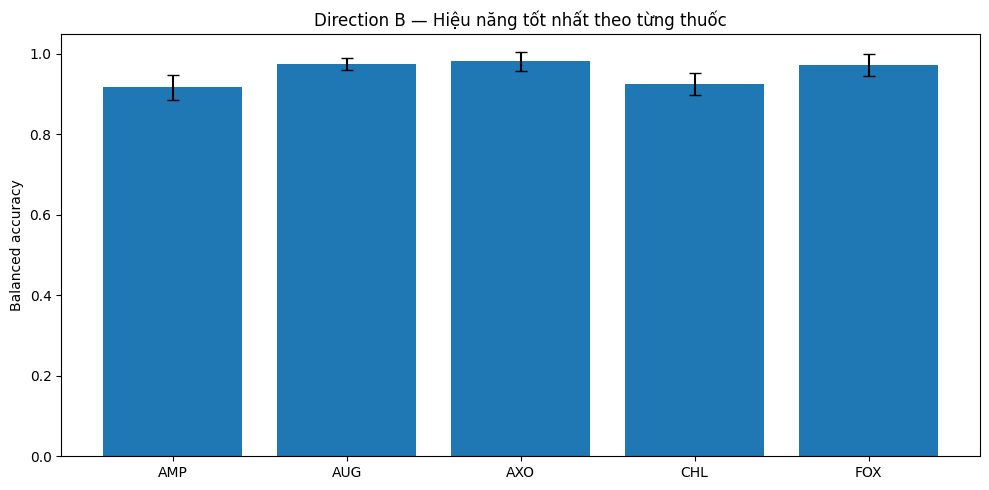

Đã lưu: /content/salmonella_direction_B/outputs/direction_B_best_balanced_accuracy.png


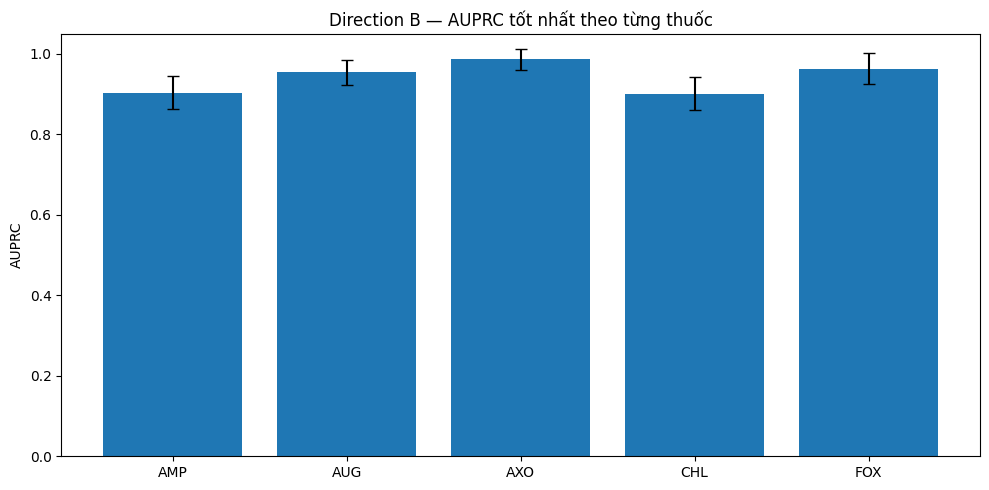

Đã lưu: /content/salmonella_direction_B/outputs/direction_B_best_auprc.png


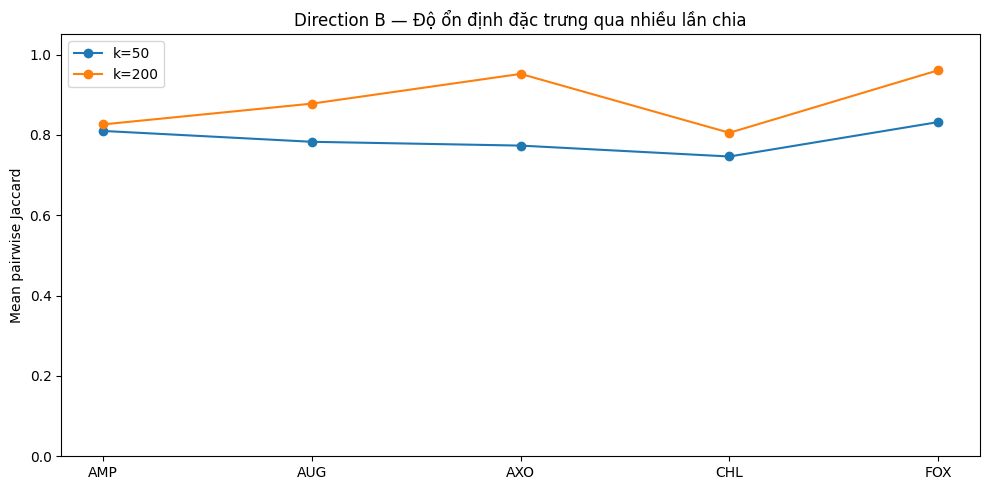

Đã lưu: /content/salmonella_direction_B/outputs/direction_B_jaccard_stability.png


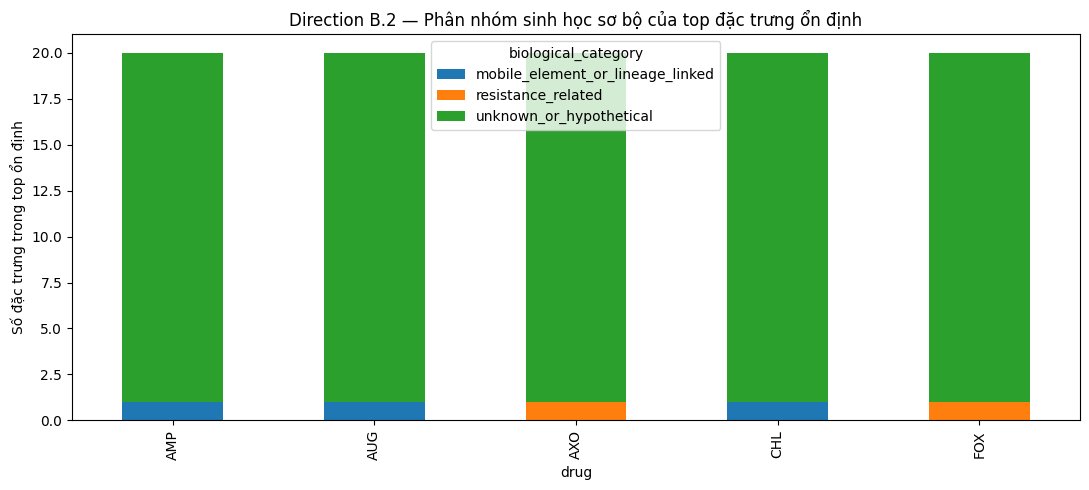

Đã lưu: /content/salmonella_direction_B/outputs/direction_B2_biological_category_counts.png


In [12]:
# 10.1 Biểu đồ hiệu năng tốt nhất theo thuốc
plot_df = best_summary.copy()
plot_df["label"] = plot_df["drug"] + "\n" + plot_df["setting"].str.replace("train_only_chi2_select_", "k=").str.replace("_from_full_accessory", "")

plt.figure(figsize=(10, 5))
plt.bar(plot_df["drug"], plot_df["balanced_accuracy_mean"], yerr=plot_df["balanced_accuracy_std"], capsize=4)
plt.ylim(0, 1.05)
plt.ylabel("Balanced accuracy")
plt.title("Direction B — Hiệu năng tốt nhất theo từng thuốc")
plt.tight_layout()
fig_path = Path(OUTPUT_DIR) / "direction_B_best_balanced_accuracy.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Đã lưu:", fig_path)

plt.figure(figsize=(10, 5))
plt.bar(plot_df["drug"], plot_df["auprc_mean"], yerr=plot_df["auprc_std"], capsize=4)
plt.ylim(0, 1.05)
plt.ylabel("AUPRC")
plt.title("Direction B — AUPRC tốt nhất theo từng thuốc")
plt.tight_layout()
fig_path = Path(OUTPUT_DIR) / "direction_B_best_auprc.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Đã lưu:", fig_path)

# 10.2 Jaccard
plt.figure(figsize=(10, 5))
for k in sorted(jaccard_all["k_features"].unique()):
    sub = jaccard_all[jaccard_all["k_features"] == k]
    plt.plot(sub["drug"], sub["jaccard_mean"], marker="o", label=f"k={k}")
plt.ylim(0, 1.05)
plt.ylabel("Mean pairwise Jaccard")
plt.title("Direction B — Độ ổn định đặc trưng qua nhiều lần chia")
plt.legend()
plt.tight_layout()
fig_path = Path(OUTPUT_DIR) / "direction_B_jaccard_stability.png"
plt.savefig(fig_path, dpi=200)
plt.show()
print("Đã lưu:", fig_path)

# 10.3 Category counts
if not category_counts.empty:
    pivot_cat = category_counts.pivot(index="drug", columns="biological_category", values="n_features").fillna(0)
    pivot_cat.plot(kind="bar", stacked=True, figsize=(11, 5))
    plt.ylabel("Số đặc trưng trong top ổn định")
    plt.title("Direction B.2 — Phân nhóm sinh học sơ bộ của top đặc trưng ổn định")
    plt.tight_layout()
    fig_path = Path(OUTPUT_DIR) / "direction_B2_biological_category_counts.png"
    plt.savefig(fig_path, dpi=200)
    plt.show()
    print("Đã lưu:", fig_path)

## 11. Lưu tất cả bảng kết quả

In [13]:
Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)

dataset_summary.to_csv(Path(OUTPUT_DIR) / "dataset_summary.csv", index=False)
perf_all.to_csv(Path(OUTPUT_DIR) / "direction_B_all_repeated_results.csv", index=False)
perf_summary.to_csv(Path(OUTPUT_DIR) / "direction_B_performance_summary.csv", index=False)
best_summary.to_csv(Path(OUTPUT_DIR) / "direction_B_best_summary.csv", index=False)
jaccard_all.to_csv(Path(OUTPUT_DIR) / "direction_B_jaccard_summary.csv", index=False)
stable_all.to_csv(Path(OUTPUT_DIR) / "direction_B_all_stable_features.csv", index=False)
top_stable_200.to_csv(Path(OUTPUT_DIR) / "direction_B_top20_stable_features_k200.csv", index=False)
overlap_df.to_csv(Path(OUTPUT_DIR) / "direction_B_overlap_with_paper_features.csv", index=False)
annotated_top_stable.to_csv(Path(OUTPUT_DIR) / "direction_B2_annotated_top_stable_features.csv", index=False)
category_counts.to_csv(Path(OUTPUT_DIR) / "direction_B2_category_counts.csv", index=False)


# Lưu thêm các bảng chú giải nâng cấp nếu đã tồn tại.
if "annotated_top_stable_enhanced" in globals():
    annotated_top_stable_enhanced.to_csv(Path(OUTPUT_DIR) / "direction_B2_enhanced_annotated_top20_stable_features.csv", index=False)
if "stable_200_annotated_all_enhanced" in globals():
    stable_200_annotated_all_enhanced.to_csv(Path(OUTPUT_DIR) / "direction_B2_enhanced_all_k200_stable_features_annotated.csv", index=False)
if "annotation_coverage_enhanced" in globals():
    annotation_coverage_enhanced.to_csv(Path(OUTPUT_DIR) / "direction_B2_enhanced_annotation_coverage.csv", index=False)
if "roary_debug_df" in globals() and isinstance(roary_debug_df, pd.DataFrame):
    roary_debug_df.to_csv(Path(OUTPUT_DIR) / "direction_B2_roary_annotation_mapping_debug.csv", index=False)

print("Đã lưu các bảng vào:", OUTPUT_DIR)
!find {OUTPUT_DIR} -maxdepth 1 -type f | sort

Đã lưu các bảng vào: /content/salmonella_direction_B/outputs
/content/salmonella_direction_B/outputs/dataset_summary.csv
/content/salmonella_direction_B/outputs/direction_B2_annotated_top_stable_features.csv
/content/salmonella_direction_B/outputs/direction_B2_biological_category_counts.png
/content/salmonella_direction_B/outputs/direction_B2_category_counts.csv
/content/salmonella_direction_B/outputs/direction_B2_enhanced_all_k200_stable_features_annotated.csv
/content/salmonella_direction_B/outputs/direction_B2_enhanced_annotated_top20_stable_features.csv
/content/salmonella_direction_B/outputs/direction_B2_enhanced_annotation_coverage.csv
/content/salmonella_direction_B/outputs/direction_B2_roary_annotation_mapping_debug.csv
/content/salmonella_direction_B/outputs/direction_B_all_repeated_results.csv
/content/salmonella_direction_B/outputs/direction_B_all_stable_features.csv
/content/salmonella_direction_B/outputs/direction_B_best_auprc.png
/content/salmonella_direction_B/outputs/di

## 12. Kết luận

In [14]:

lines = []
lines.append("# KẾT LUẬN DIRECTION B")
lines.append("")
lines.append("## 1. Thiết kế thí nghiệm")
lines.append(f"- Lặp {N_SPLITS} lần chia dữ liệu.")
lines.append("- Mỗi lần chia dữ liệu trước, sau đó chỉ chọn đặc trưng trên tập huấn luyện.")
lines.append(f"- Số đặc trưng được thử: {FEATURE_COUNTS}.")
lines.append("- Mục tiêu: kiểm tra hiệu năng, độ ổn định đặc trưng và diễn giải sinh học sơ bộ.")
lines.append("")

lines.append("## 2. Hiệu năng tốt nhất theo từng thuốc")
for _, r in best_summary.iterrows():
    lines.append(
        f"- {r['drug']}: {r['setting']} với {r['model']}, "
        f"balanced accuracy = {r['balanced_accuracy_mean']:.3f} ± {r['balanced_accuracy_std']:.3f}, "
        f"AUPRC = {r['auprc_mean']:.3f} ± {r['auprc_std']:.3f}."
    )
lines.append("")

lines.append("## 3. Độ ổn định đặc trưng")
for drug in DRUGS:
    sub = jaccard_all[jaccard_all["drug"] == drug].sort_values("jaccard_mean", ascending=False)
    if len(sub):
        r = sub.iloc[0]
        lines.append(
            f"- {drug}: ổn định nhất ở k={int(r['k_features'])}, "
            f"Jaccard = {r['jaccard_mean']:.3f} ± {r['jaccard_std']:.3f}."
        )
lines.append("")

lines.append("## 4. Độ phủ chú giải sinh học")
if "annotation_coverage_enhanced" in globals():
    for _, r in annotation_coverage_enhanced.iterrows():
        lines.append(
            f"- {r['drug']}: chú giải được {int(r['annotated_features'])}/{int(r['top_features'])} "
            f"đặc trưng ổn định top, coverage = {r['annotation_coverage']:.2f}."
        )
else:
    lines.append("- Notebook dùng bảng chú giải sơ bộ; chưa có bảng coverage nâng cấp.")
lines.append("")

lines.append("## 5. Phân nhóm sinh học sơ bộ")
if not category_counts.empty:
    for drug in DRUGS:
        sub = category_counts[category_counts["drug"] == drug]
        desc = ", ".join([f"{row['biological_category']}: {int(row['n_features'])}" for _, row in sub.iterrows()])
        lines.append(f"- {drug}: {desc}")
else:
    lines.append("- Chưa có đủ chú giải để phân nhóm sinh học.")
lines.append("")

lines.append("## 6. Kết luận chung")
lines.append(
    "Direction B cho thấy việc chọn đặc trưng chỉ trên tập huấn luyện không chỉ duy trì hiệu năng dự đoán cao, "
    "mà còn tạo ra các tập đặc trưng có độ ổn định đáng kể qua nhiều lần chia dữ liệu. "
    "Khối chú giải nâng cấp giúp tăng khả năng diễn giải sinh học bằng cách map thêm locus tag từ bảng Roary, "
    "nhưng các kết luận cơ chế vẫn cần được trình bày cẩn thận vì một số đặc trưng có thể phản ánh vùng di động hoặc dòng vi khuẩn."
)

conclusion_text = "\n".join(lines)
print(conclusion_text)

conclusion_path = Path(OUTPUT_DIR) / "AUTO_CONCLUSION_DIRECTION_B_ENHANCED.md"
conclusion_path.write_text(conclusion_text, encoding="utf-8")
print("\nĐã lưu:", conclusion_path)


# KẾT LUẬN DIRECTION B

## 1. Thiết kế thí nghiệm
- Lặp 30 lần chia dữ liệu.
- Mỗi lần chia dữ liệu trước, sau đó chỉ chọn đặc trưng trên tập huấn luyện.
- Số đặc trưng được thử: [50, 200].
- Mục tiêu: kiểm tra hiệu năng, độ ổn định đặc trưng và diễn giải sinh học sơ bộ.

## 2. Hiệu năng tốt nhất theo từng thuốc
- AMP: train_only_chi2_select_200_from_full_accessory với logistic_regression, balanced accuracy = 0.917 ± 0.030, AUPRC = 0.904 ± 0.041.
- AUG: train_only_chi2_select_200_from_full_accessory với logistic_regression, balanced accuracy = 0.976 ± 0.015, AUPRC = 0.954 ± 0.031.
- AXO: train_only_chi2_select_200_from_full_accessory với logistic_regression, balanced accuracy = 0.981 ± 0.024, AUPRC = 0.987 ± 0.026.
- CHL: train_only_chi2_select_200_from_full_accessory với logistic_regression, balanced accuracy = 0.927 ± 0.027, AUPRC = 0.901 ± 0.041.
- FOX: train_only_chi2_select_50_from_full_accessory với logistic_regression, balanced accuracy = 0.974 ± 0.027, AUPRC = 0.963 ± 0.038.

#